# Retrieval evaluation — judged by people

This notebook measures **Precision@5** and **Recall@5**. Just those two.

It uses the same 48 questions as the generation notebook. The difference is who decides what
counts as a good chunk. Before, a formula guessed it by comparing words. Here, **a person reads
each chunk and says yes or no.**

## Why a person is better than a formula

A formula compares the words in the chunk to the words in the gold answer. That goes wrong in two
ways:

- A chunk can give the same advice in different words. The formula says "not relevant". It is.
- A chunk can share many words with the answer and still be about a different problem. The formula
  says "relevant". It is not.

A person reads the chunk and just knows. That makes these numbers the ones to put in the report.

## What you will do

1. The notebook retrieves the top chunks for each of the 48 questions.
2. You read each chunk and click **Yes** or **No**.
3. The notebook counts the yeses and works out the scores.

There are 48 questions and you judge 10 chunks each, so 480 decisions, about 40 minutes.
You can stop any time and come back — your answers are saved after every click.

You can also split the work across your team. Each person does a slice of the questions and the
notebook merges everyone's files at the end.

## What "relevant" means

A chunk is relevant if **a farmer asking this question would be helped by it.** It does not have to
match the gold answer word for word. It does have to be about the same crop and the same problem,
and it has to say something useful.

Say **No** if the chunk is about a different crop, a different problem, or is just a heading, a
phone number, or filler text.

## 1. Packages

In [4]:
!pip install -q sacrebleu rank-bm25 qdrant-client sentence-transformers ipywidgets --break-system-packages 2>/dev/null || pip install -q sacrebleu rank-bm25 qdrant-client sentence-transformers ipywidgets

import importlib
for _m in ("sacrebleu", "qdrant_client", "sentence_transformers"):
    try:
        importlib.import_module(_m)
        print(f"   ok   {_m}")
    except ImportError as _e:
        print(f"   FAIL {_m}: {_e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.4 MB/s eta 0:00:00
   ok   sacrebleu
   ok   qdrant_client
   ok   sentence_transformers


## 2. Settings

**`JUDGE_DEPTH`** is how many chunks you judge per question. It has to be more than 5.

Recall@5 asks: *of all the good chunks, how many were in the top 5?* We only know which chunks are
good among the ones you judged. So if you only judge 5, Recall@5 is always 1.0 and tells you
nothing.

`JUDGE_DEPTH = 10` is the default. You judge 10 chunks and score the top 5 of them, so Recall@5 is
a real number with something behind it. Raise it to 15 or 20 if you want a stronger figure and have
the time; each extra chunk adds about 48 more decisions.

**Splitting the work.** Set `JUDGE_FROM` and `JUDGE_TO` to do a slice of the questions, and put your
name in `JUDGE_NAME`. Everyone saves a separate file and section 9 merges them.

| person | JUDGE_FROM | JUDGE_TO |
|---|---|---|
| 1 | 0 | 10 |
| 2 | 10 | 20 |
| 3 | 20 | 30 |
| 4 | 30 | 40 |
| 5 | 40 | 48 |

At 10 chunks per question that is under 10 minutes each.

In [5]:
# ---- where the index comes from ----------------------------------------------------------------
# Nothing is downloaded. The snapshot and manifest are read from the notebook attached
# under Input. Leave this as None and section 3 finds them by searching /kaggle/input.
INPUT_DIR = None      # or set it directly, e.g. "/kaggle/input/distil-real/rag_production_bge_m3"

# ---- who is judging, and which questions -------------------------------------------------------
JUDGE_NAME  = "harliv"     # your name. Used in the filename so files do not overwrite each other.
JUDGE_FROM  = 0            # first question (0 = the first one)
JUDGE_TO    = 48           # last question, not included

# ---- how many chunks to judge per question ------------------------------------------------------
JUDGE_DEPTH = 10           # judge 10, score the top 5. Must be more than 5.
K           = 5            # the only k we report

# ---- retrieval settings (same as the other notebooks) --------------------------------------------
DENSE_DEPTH  = 50
SPARSE_DEPTH = 50
RRF_K        = 60
RRF_WEIGHTS  = {"dense": 1.0, "sparse": 0.6}
DEDUP_ON     = True
USE_BM25     = True
BM25_MAX_DOCS = 250_000

CHUNK_PREVIEW_CHARS = 900   # how much of each chunk to show you

SMOKE_TEST = False          # True = only the first 8 questions, to check the notebook runs
CTX_TOP_K  = None           # set just below; the search function reads it as its default

import os, re, json, time, math, shutil, hashlib, subprocess, sys, zipfile, tarfile, glob, gc
import random
random.seed(13)

IS_KAGGLE = os.path.isdir("/kaggle/input") or bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))
OUT_ROOT  = "/kaggle/working" if IS_KAGGLE else os.path.abspath("./eval_run")
WORK_ROOT = "/kaggle/temp"    if os.path.isdir("/kaggle/temp") else OUT_ROOT
OUTPUT_DIR = os.path.join(OUT_ROOT, "human_eval")
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
for _d in (OUTPUT_DIR, FIG_DIR):
    os.makedirs(_d, exist_ok=True)

# your answers are saved here after every click
JUDGE_FILE = os.path.join(OUTPUT_DIR, f"judgements_{JUDGE_NAME}.json")

CTX_TOP_K = JUDGE_DEPTH     # the search returns as many chunks as you are going to judge
RUN_GENERATION = False      # no models are loaded in this notebook

if SMOKE_TEST:
    JUDGE_TO = min(JUDGE_FROM + 8, JUDGE_TO)
def _find(dirpath, pattern):
    hits = sorted(glob.glob(os.path.join(dirpath, "**", pattern), recursive=True))
    return hits[0] if hits else None

def _free_gb(path=WORK_ROOT):
    st = os.statvfs(path)
    return st.f_bavail * st.f_frsize / 1e9

RUN_START = time.time()
def minutes_used():
    return (time.time() - RUN_START) / 60

print(f"judge       : {JUDGE_NAME}")
print(f"questions   : {JUDGE_FROM} to {JUDGE_TO}")
print(f"chunks each : {JUDGE_DEPTH}")
print(f"to decide   : about {(JUDGE_TO - JUDGE_FROM) * JUDGE_DEPTH} chunks "
      f"(~{(JUDGE_TO - JUDGE_FROM) * JUDGE_DEPTH * 5 / 60:.0f} minutes at 5 seconds each)")
print(f"saved to    : {JUDGE_FILE}")
print(f"free disk   : {_free_gb():.1f} GB")

if JUDGE_DEPTH <= K:
    print(f"\n[STOP] JUDGE_DEPTH is {JUDGE_DEPTH}, which is not more than K={K}.")
    print(f"       Recall@{K} would be 1.0 for every question -- arithmetic, not a result.")
    print(f"       Set JUDGE_DEPTH to at least {K + 5}.")


judge       : harliv
questions   : 0 to 48
chunks each : 10
to decide   : about 480 chunks (~40 minutes at 5 seconds each)
saved to    : /kaggle/working/human_eval/judgements_harliv.json
free disk   : 20.9 GB


## 3. Find the index files in your Kaggle Input

Nothing is downloaded. The snapshot and `manifest.json` come from the notebook you attached under
**Input** (the `distil real` entry in the sidebar).

This cell searches `/kaggle/input` for them, so it does not matter what Kaggle named the folder. It
needs exactly two things:

- `manifest.json` — the settings the index was built with: model name, vector size, collection name
- the `.snapshot` file — the index itself, about 3.8 GB

`kcc_pool.csv` and the other JSON files in that folder are ignored. The 48 questions are written
into this notebook in section 8, so `kcc_qa_pairs.csv` is not needed either.

If it cannot find something, it lists what it did find so you can set `INPUT_DIR` by hand.

In [6]:
INPUT_ROOTS = [INPUT_DIR] if INPUT_DIR else ["/kaggle/input"]

def _search(pattern):
    hits = []
    for root in INPUT_ROOTS:
        hits += glob.glob(os.path.join(root, "**", pattern), recursive=True)
    return sorted(set(hits))

# ---- manifest.json ------------------------------------------------------------------------------
_man = [p for p in _search("manifest.json") if "rag_production" in p] or _search("manifest.json")
if not _man:
    print("Could not find manifest.json. Here is what is attached:\n")
    for p in sorted(glob.glob("/kaggle/input/*/**", recursive=True))[:60]:
        print("   " + p)
    raise FileNotFoundError(
        "No manifest.json under /kaggle/input.\n"
        "Attach the notebook that produced the index (Input -> Add Input -> Notebooks),\n"
        "or set INPUT_DIR in section 2 to the folder holding manifest.json.")
MANIFEST_PATH = _man[0]
MANIFEST = json.load(open(MANIFEST_PATH, encoding="utf-8"))

REQUIRED = ["collection", "embed_model", "embed_dim", "max_seq_length",
            "query_prefix", "doc_prefix", "tiers", "fusion_weights", "top_k_default"]
_missing = [k for k in REQUIRED if k not in MANIFEST]
if _missing:
    raise KeyError(f"manifest.json is missing {_missing}. These say which model to use and how "
                   "to prepare the query. Without them the vectors would be read with the wrong "
                   "settings and every result would be quietly wrong.")
COLLECTION_NAME = MANIFEST["collection"]

# ---- the snapshot -------------------------------------------------------------------------------
_snaps = [p for p in _search("*.snapshot") if os.path.getsize(p) > 100_000_000]
if not _snaps:
    _all = _search("*.snapshot")
    raise FileNotFoundError(
        "No .snapshot file over 100 MB under /kaggle/input.\n"
        + (f"Found these, but they are too small to be the real index: {_all}\n" if _all else "")
        + "The index file is about 3.8 GB. Check the attached notebook actually contains it.")
SNAPSHOT_PATH = max(_snaps, key=os.path.getsize)

print(f"manifest : {MANIFEST_PATH}")
print(f"snapshot : {SNAPSHOT_PATH}  ({os.path.getsize(SNAPSHOT_PATH)/1e9:.2f} GB)\n")
print("index settings:")
for k in ("collection", "embed_model", "embed_dim", "max_seq_length",
          "query_prefix", "doc_prefix", "top_k_default", "tiers", "n_chunks", "built_utc"):
    print(f"   {k:<16} {MANIFEST.get(k)}")

# Kaggle mounts inputs read-only. Restoring a snapshot needs somewhere writable, so check
# there is room before spending minutes on an upload that cannot finish.
if _free_gb() < 6:
    print(f"\n[WARN] only {_free_gb():.1f} GB free. Restoring the index needs about 5 GB.")


manifest : /kaggle/input/notebooks/harlivsingh1122777/distil-real/rag_production_bge_m3/manifest.json
snapshot : /kaggle/input/notebooks/harlivsingh1122777/distil-real/rag_production_bge_m3/agri_knowledge-79188001122225-2026-07-27-13-03-44.snapshot  (3.80 GB)

index settings:
   collection       agri_knowledge
   embed_model      BAAI/bge-m3
   embed_dim        1024
   max_seq_length   512
   query_prefix     
   doc_prefix       
   top_k_default    5
   tiers            {'fallback': 0.56, 'grounded': 0.66}
   n_chunks         723439
   built_utc        2026-07-27T13:10:54Z


## 4. Start Qdrant and restore the index

Kaggle has no Docker, so the plain binary is downloaded and run. The snapshot upload is the slow
step — several minutes for a 3.9 GB index — and is skipped entirely if the collection is already
present, which makes this cell safe to re-run.

In [7]:
import requests
import pandas as pd

QDRANT_STORAGE = os.path.join(WORK_ROOT, "qdrant_storage")
QDRANT_BIN     = os.path.join(WORK_ROOT, "qdrant")
QDRANT_URL     = "http://localhost:6333"
os.makedirs(QDRANT_STORAGE, exist_ok=True)

def qdrant_alive(timeout=1):
    try:
        return requests.get(f"{QDRANT_URL}/readyz", timeout=timeout).ok
    except Exception:
        return False

def binary_ok(path=QDRANT_BIN):
    """A downloaded file existing is not the same as it working -- actually run it."""
    if not os.path.exists(path):
        return False
    try:
        return subprocess.run([path, "--version"], capture_output=True,
                              timeout=60).returncode == 0
    except Exception:
        return False

if qdrant_alive():
    print("Qdrant already running on :6333")
else:
    if not binary_ok():
        if os.path.exists(QDRANT_BIN):
            os.remove(QDRANT_BIN)
        rel = requests.get("https://api.github.com/repos/qdrant/qdrant/releases/latest",
                           timeout=30).json()
        asset = None
        for suffix in ("x86_64-unknown-linux-musl.tar.gz",   # static, no system libs needed
                       "x86_64-unknown-linux-gnu.tar.gz"):
            asset = next((a for a in rel["assets"] if a["name"].endswith(suffix)), None)
            if asset:
                break
        if asset is None:
            raise RuntimeError("no linux x86_64 asset in " + rel["tag_name"])
        print(f"downloading qdrant {rel['tag_name']} ...")
        _tgz = os.path.join(WORK_ROOT, "q.tar.gz")
        with open(_tgz, "wb") as f:
            f.write(requests.get(asset["browser_download_url"], timeout=600).content)
        with tarfile.open(_tgz) as t:
            try:
                t.extractall(WORK_ROOT, filter="data")
            except TypeError:
                t.extractall(WORK_ROOT)
        os.chmod(QDRANT_BIN, 0o755)
        os.remove(_tgz)
        if not binary_ok():
            raise RuntimeError("downloaded qdrant will not run here")

    _log = os.path.join(WORK_ROOT, "qdrant.log")
    env = dict(os.environ, QDRANT__STORAGE__STORAGE_PATH=QDRANT_STORAGE,
               QDRANT__TELEMETRY_DISABLED="true")
    qdrant_proc = subprocess.Popen([QDRANT_BIN], env=env, cwd=WORK_ROOT,
                                   stdout=open(_log, "w"), stderr=subprocess.STDOUT)
    for _ in range(120):
        if qdrant_alive():
            break
        if qdrant_proc.poll() is not None:
            raise RuntimeError("qdrant exited early -- log:\n" + open(_log).read()[-1500:])
        time.sleep(1)
    else:
        raise RuntimeError(f"qdrant not ready in 120s -- see {_log}")
    print("Qdrant ready on :6333")

# ---- restore -------------------------------------------------------------------------------------
_cols = requests.get(f"{QDRANT_URL}/collections", timeout=30).json()["result"]["collections"]
if any(c["name"] == COLLECTION_NAME for c in _cols):
    print(f"collection '{COLLECTION_NAME}' already restored -- skipping upload")
else:
    print(f"uploading {os.path.getsize(SNAPSHOT_PATH)/1e9:.2f} GB snapshot "
          "-- the slow step, several minutes ...")
    t0 = time.time()
    with open(SNAPSHOT_PATH, "rb") as fh:
        r = requests.post(
            f"{QDRANT_URL}/collections/{COLLECTION_NAME}/snapshots/upload?priority=snapshot",
            files={"snapshot": (os.path.basename(SNAPSHOT_PATH), fh)}, timeout=7200)
    r.raise_for_status()
    print(f"restored in {(time.time()-t0)/60:.1f} min")

from qdrant_client import QdrantClient
qdrant_client = QdrantClient(url=QDRANT_URL, timeout=600)
info = qdrant_client.get_collection(COLLECTION_NAME)
print(f"\ncollection '{COLLECTION_NAME}'")
print(f"   points       : {info.points_count:,}")
print(f"   indexed vecs : {info.indexed_vectors_count:,}")
print(f"   status       : {info.status}")
if info.points_count == 0:
    raise RuntimeError("the collection restored with zero points -- the snapshot is not the "
                       "production index.")
print(f"\n{minutes_used():.0f} min used so far")

downloading qdrant v1.19.0 ...
Qdrant ready on :6333
uploading 3.80 GB snapshot -- the slow step, several minutes ...
restored in 1.3 min

collection 'agri_knowledge'
   points       : 723,439
   indexed vecs : 723,439
   status       : yellow

1 min used so far


## 5. Small helper functions

Only three things happen here.

**A tokenizer that handles Hindi.** The usual pattern `[\u0900-\u097F]+` looks like "all
Devanagari", but that range includes the danda `।`, which is a full stop. So it produces `हैं।`
instead of `हैं`, and nothing matches. This one leaves the danda out.

**A duplicate check.** The KCC data repeats the same advice many times, word for word. If five
copies of one record fill the top 5, that is one piece of information, not five. We drop the copies
before you judge, so you do not read the same thing five times and so the scores are not inflated.

**RRF**, the method used to combine the two searches. It only looks at position in each list, never
at scores, so the two searches do not need to be on the same scale.

In [8]:
import math
from collections import Counter, defaultdict

DEVA_DIGITS = str.maketrans("०१२३४५६७८९", "0123456789")

# danda (U+0964) and double danda (U+0965) are punctuation, so they are left out of the range
_TOKEN_RE = re.compile(r"[\u0900-\u0963\u0966-\u097F]+|[A-Za-z]+|[0-9]+")

_STOP = {"the", "and", "for", "with", "this", "that", "from", "are", "was", "will", "can",
         "should", "use", "used", "using", "per", "may", "any", "all", "not", "you", "your",
         "में", "के", "की", "का", "है", "हैं", "और", "से", "को", "पर", "एक", "यह", "कि",
         "लिए", "करें", "कर", "रूप", "तथा", "या", "भी", "साथ", "प्रति"}


def toks(text):
    return [t.lower() for t in _TOKEN_RE.findall(str(text or "").translate(DEVA_DIGITS))]


def content_toks(text):
    return [t for t in toks(text) if t not in _STOP and len(t) > 1]


def dedup_key(text, n=160):
    """Two chunks with the same first 160 characters are treated as the same chunk."""
    return re.sub(r"\s+", " ", str(text or "").lower())[:n]


def rrf_fuse(rankings, k=60, weights=None):
    """Combine ranked lists by position: score = sum of w / (k + rank)."""
    weights = weights or {}
    scores = defaultdict(float)
    for name, ranked in rankings.items():
        w = weights.get(name, 1.0)
        for rank, key in enumerate(ranked, 1):
            scores[key] += w / (k + rank)
    return sorted(scores.items(), key=lambda kv: kv[1], reverse=True)


def deva_ratio(s):
    letters = [ch for ch in str(s or "") if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for ch in letters if "\u0900" <= ch <= "\u097F") / len(letters)


def detect_script(text):
    """Three groups, so Hinglish is not filed as English."""
    r = deva_ratio(text)
    if r > 0.4:
        return "hi"
    if re.search(r"\b(ki|ka|ke|mein|kaise|kya|chahiye|karein|bataye|jankari|hai)\b",
                 str(text or "").lower()):
        return "hinglish"
    return "en"


# crop names in the index are canonical (rice, bajra, urad); our question list uses everyday
# names (Paddy, Pearl Millet, Black Gram). This maps ours onto theirs, for grouping only.
CROP_CANON = {
    "paddy": "rice", "rice": "rice", "dhan": "rice", "wheat": "wheat", "gehun": "wheat",
    "maize": "maize", "makka": "maize", "sugarcane": "sugarcane", "ganna": "sugarcane",
    "mustard": "mustard", "sarson": "mustard", "black gram": "urad", "urad": "urad",
    "pearl millet": "bajra", "bajra": "bajra", "sesame": "sesame", "til": "sesame",
    "groundnut": "groundnut", "chillies": "chilli", "chilli": "chilli", "onion": "onion",
    "garlic": "garlic", "potato": "potato", "tomato": "tomato", "banana": "banana",
    "mango": "mango", "guava": "guava", "litchi": "litchi", "sapota": "sapota",
    "cauliflower": "cauliflower", "brinjal": "brinjal", "bottle gourd": "bottle gourd",
    "aloe vera": "aloe vera", "rose": "rose", "pea": "pea",
}
_CROP_PAREN = re.compile(r"^([^(]+?)\s*\((.*)\)\s*$")


def canon_crop(raw):
    if raw is None:
        return None
    c = re.sub(r"\s+", " ", str(raw).strip().lower())
    if c in CROP_CANON:
        return CROP_CANON[c]
    m = _CROP_PAREN.match(c)
    if m:
        base = m.group(1).strip()
        if base in CROP_CANON:
            return CROP_CANON[base]
        for alias in re.split(r"[/,]", m.group(2)):
            if alias.strip() in CROP_CANON:
                return CROP_CANON[alias.strip()]
        return base
    return c


QT_CANON = {"plant protection": "plant protection", "disease management": "plant protection",
            "pest management": "plant protection", "weed management": "weed management",
            "nutrient management": "nutrient management", "varieties": "varieties",
            "cultural practices": "cultural practices"}


def canon_qt(raw):
    if not raw:
        return None
    q = re.sub(r"\s+", " ", str(raw).strip().lower())
    return QT_CANON.get(q, q)


def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=13):
    """A range the true average is probably in. With 48 questions the range is wide,
    and that is the point: it stops us reading meaning into small differences."""
    import random as _r
    vals = [v for v in values if v is not None]
    if not vals:
        return (None, None, None)
    rng = _r.Random(seed)
    n = len(vals)
    means = sorted(sum(vals[rng.randrange(n)] for _ in range(n)) / n for _ in range(n_boot))
    return (sum(vals) / n, means[int(alpha / 2 * n_boot)],
            means[int((1 - alpha / 2) * n_boot) - 1])


assert "हैं" in toks("बाजरा हैं।")
assert canon_crop("Paddy") == "rice"
assert detect_script("Phoolgobhi ki varieties chahiye?") == "hinglish"
print("helpers ready")


helpers ready


## 6. The search

Same search as the other notebooks: BGE-M3 for meaning, BM25 for exact words, combined with RRF.
Nothing about it is changed here — we are measuring it, not tuning it.

The only difference is that we ask for `JUDGE_DEPTH` chunks instead of 5, because you need more
than 10 in front of you for Recall@10 to mean anything.

In [9]:
import torch, numpy as np
from sentence_transformers import SentenceTransformer
from qdrant_client.models import Filter, FieldCondition, MatchValue
from rank_bm25 import BM25Okapi

EMBED_MODEL_NAME = MANIFEST["embed_model"]
QUERY_PREFIX     = MANIFEST["query_prefix"]
DOC_PREFIX       = MANIFEST["doc_prefix"]
TIER_GROUNDED    = MANIFEST["tiers"]["grounded"]
TIER_FALLBACK    = MANIFEST["tiers"]["fallback"]
FUSION_WEIGHTS   = MANIFEST["fusion_weights"]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"loading {EMBED_MODEL_NAME} on {device} ...")
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=device)
embed_model.max_seq_length = MANIFEST["max_seq_length"]
_dim = embed_model.get_sentence_embedding_dimension()
assert _dim == MANIFEST["embed_dim"], (
    f"dimension mismatch: model gives {_dim}, index built with {MANIFEST['embed_dim']}")
print(f"   dim {_dim}   max_seq {MANIFEST['max_seq_length']}   "
      f"prefixes query={QUERY_PREFIX!r} doc={DOC_PREFIX!r}")
print(f"   tiers (RAW cosine): abstain < {TIER_FALLBACK} <= fallback < {TIER_GROUNDED} <= grounded")


def embed(texts, is_query=True, batch_size=32):
    pre = QUERY_PREFIX if is_query else DOC_PREFIX
    return embed_model.encode([pre + t for t in texts], normalize_embeddings=True,
                              batch_size=batch_size, show_progress_bar=False)


# ================================================================== BM25
_BM25 = {"index": None, "keys": [], "meta": [], "n": 0}

def build_bm25(max_docs=BM25_MAX_DOCS):
    if _BM25["index"] is not None:
        return
    print(f"building BM25 (cap {max_docs:,} docs, script-aware tokenizer) ...")
    t0, offset, seen = time.time(), None, 0
    corpus = []
    while seen < max_docs:
        pts, offset = qdrant_client.scroll(
            collection_name=COLLECTION_NAME, limit=min(10_000, max_docs - seen),
            offset=offset, with_payload=True, with_vectors=False)
        if not pts:
            break
        for p in pts:
            pl = p.payload or {}
            txt = pl.get("text", "")
            if not txt:
                continue
            corpus.append(toks(txt))
            _BM25["keys"].append(pl.get("chunk_id") or f"pt::{p.id}")
            _BM25["meta"].append({
                "text": txt, "source_type": pl.get("source_type", ""),
                "crop": pl.get("crop"), "query_type": pl.get("query_type"),
                "district": pl.get("district"), "chunk_id": pl.get("chunk_id"),
                "point_id": p.id})
            seen += 1
        if offset is None:
            break
    if not corpus:
        print("[WARN] BM25 corpus empty -- sparse retrieval disabled")
        return
    _BM25["index"] = BM25Okapi(corpus)
    _BM25["n"] = len(corpus)
    print(f"   {len(corpus):,} docs in {(time.time()-t0)/60:.1f} min "
          f"({'FULL index' if len(corpus) >= info.points_count else 'SAMPLED -- recorded in manifest'})")


def bm25_search(query_text, depth=SPARSE_DEPTH):
    if _BM25["index"] is None:
        build_bm25()
    if _BM25["index"] is None:
        return []
    q = toks(query_text)
    if not q:
        return []
    scores = _BM25["index"].get_scores(q)
    idx = np.argsort(-scores)[:depth]
    out = []
    for i in idx:
        if scores[i] <= 0:
            continue
        m = _BM25["meta"][i]
        out.append({**m, "key": _BM25["keys"][i], "bm25_score": float(scores[i]),
                    "raw_cosine": None})
    return out


# ================================================================== dense
def dense_search(qvec, depth=DENSE_DEPTH, intent="general", buckets=("pdf", "kcc")):
    weights = FUSION_WEIGHTS.get(intent, FUSION_WEIGHTS.get("general", {}))
    out = []
    for stype in buckets:
        pts = qdrant_client.query_points(
            collection_name=COLLECTION_NAME,
            query=qvec.tolist() if hasattr(qvec, "tolist") else qvec,
            query_filter=Filter(must=[FieldCondition(
                key="source_type", match=MatchValue(value=stype))]),
            limit=depth, with_payload=True).points
        for h in pts:
            p = h.payload or {}
            out.append({
                "key": p.get("chunk_id") or f"pt::{h.id}",
                "text": p.get("text", ""), "source_type": stype,
                "crop": p.get("crop"), "query_type": p.get("query_type"),
                "district": p.get("district"), "chunk_id": p.get("chunk_id"),
                "point_id": h.id,
                "raw_cosine": float(h.score),                       # NEVER overwritten
                "bucket_weighted": float(h.score) * weights.get(stype, 1.0),
            })
    # bucket weighting decides the dense ordering; raw cosine decides the tier
    out.sort(key=lambda x: x["bucket_weighted"], reverse=True)
    return out


# ================================================================== fusion + dedup
def _dedup(hits):
    if not DEDUP_ON:
        return hits
    seen, out = set(), []
    for h in hits:
        k = dedup_key(h["text"])
        if k in seen:
            continue
        seen.add(k)
        out.append(h)
    return out


def search(query_text, qvec=None, top_k=CTX_TOP_K, mode="rrf", intent="general",
           dense_depth=DENSE_DEPTH, sparse_depth=SPARSE_DEPTH):
    """mode: 'dense' | 'bm25' | 'rrf'. Returns fused top_k plus an honest tier."""
    if qvec is None and mode != "bm25":
        qvec = embed([query_text])[0]

    dense = dense_search(qvec, depth=dense_depth, intent=intent) if mode != "bm25" else []
    sparse = (bm25_search(query_text, depth=sparse_depth)
              if USE_BM25 and mode != "dense" else [])

    by_key = {}
    for h in dense + sparse:
        prev = by_key.get(h["key"])
        if prev is None:
            by_key[h["key"]] = dict(h)
        else:
            # keep whichever record actually carries a cosine
            if prev.get("raw_cosine") is None and h.get("raw_cosine") is not None:
                prev["raw_cosine"] = h["raw_cosine"]
            prev.setdefault("bm25_score", h.get("bm25_score"))

    if mode == "dense":
        ranked = [h["key"] for h in dense]
    elif mode == "bm25":
        ranked = [h["key"] for h in sparse]
    else:
        ranked = [k for k, _ in rrf_fuse(
            {"dense": [h["key"] for h in dense], "sparse": [h["key"] for h in sparse]},
            k=RRF_K, weights=RRF_WEIGHTS)]

    fused_scores = dict(rrf_fuse(
        {"dense": [h["key"] for h in dense], "sparse": [h["key"] for h in sparse]},
        k=RRF_K, weights=RRF_WEIGHTS)) if mode == "rrf" else {}

    hits = []
    for r, k in enumerate(ranked, 1):
        h = dict(by_key[k])
        h["rank"] = r
        h["fused_score"] = fused_scores.get(k)
        hits.append(h)
    hits = _dedup(hits)[:top_k]

    # ---- the tier gate reads RAW COSINE, which is what it was calibrated on ----
    cosines = [h["raw_cosine"] for h in hits if h.get("raw_cosine") is not None]
    best_cos = max(cosines) if cosines else 0.0
    tier = ("grounded" if best_cos >= TIER_GROUNDED
            else "fallback_with_disclaimer" if best_cos >= TIER_FALLBACK
            else "abstain_out_of_scope")
    return {"tier": tier, "top_cosine": round(best_cos, 4), "mode": mode, "results": hits}


if USE_BM25:
    build_bm25()
_smoke = search("गेहूं की किस्मों के बारे में जानकारी?", top_k=5)
print(f"\nsmoke: mode={_smoke['mode']} tier={_smoke['tier']} cos={_smoke['top_cosine']} "
      f"n={len(_smoke['results'])} sources={[h['source_type'] for h in _smoke['results']]}")
assert _smoke["results"], "retrieval returned nothing -- stop and check the collection"
assert _smoke["top_cosine"] <= 1.0001, "tier is not reading a cosine"
print(f"{minutes_used():.0f} min used")


loading BAAI/bge-m3 on cuda ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

/tmp/ipykernel_58/2055193597.py:17: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  _dim = embed_model.get_sentence_embedding_dimension()


   dim 1024   max_seq 512   prefixes query='' doc=''
   tiers (RAW cosine): abstain < 0.56 <= fallback < 0.66 <= grounded
building BM25 (cap 250,000 docs, script-aware tokenizer) ...
   250,000 docs in 0.6 min (SAMPLED -- recorded in manifest)

smoke: mode=rrf tier=grounded cos=0.7917 n=5 sources=['kcc', 'kcc', 'kcc', 'kcc', 'kcc']
2 min used


## 7. The 48 questions

Exactly the same list used in the generation notebook, so the two sets of results line up.

Each question comes with a gold answer written by hand in the KCC style. You will see it while
judging, as a reminder of what the question is really asking. **Do not treat it as the only right
answer** — a chunk that gives the same advice in different words is still relevant.

In [10]:
# ---- USE CURATED QUESTION SET WITH GOLDEN ANSWERS ----
# 50 curated farmer questions with expert golden answers from KCC knowledge base

CURATED_QA = [
    # Crop & Variety Information
    {
        "query": "बाजरा फसल की किस्मों की जानकारी चाहिए?",
        "answer": "बाजरा फसल की विभिन्न किस्में पूसा-322, पूसा-23, आई एम-451, जीबी-316, पीएचबी-14, आईसीएमएच-356, एमएच 169, एचएचबी 67, पीएचबी 47, पीएचबी 2168, पीएचबी 2884 हैं।",
        "crop": "Pearl Millet (Bajra)",
        "type": "Varieties"
    },
    {
        "query": "Phoolgobhi (Cauliflower) ki varieties ke baare mein information chahiye?",
        "answer": "फूलगोभी की किस्में अर्ली कुंवारी, पूसा दीपाली, समर किंग, पंत शुभ्रा, हिसार-114, एस-1, नरेंद्र गोभी-1, पूसा अगहनी, इंप्रूव्ड जापानी, पूसा शंकर 2, शंकर शीतल, शंकर मोती, पूसा शरद, पूसा कतिकी, पूसा स्नोबॉल-k1 हैं।",
        "crop": "Cauliflower",
        "type": "Varieties"
    },
    {
        "query": "Til (Sesame) ki varieties ke baare mein information chahiye.",
        "answer": "तिल की तरुण, शेखर, प्रगति, आरटी 351 और टी4 किस्मों की बुवाई करें।",
        "crop": "Sesame",
        "type": "Varieties"
    },
    {
        "query": "केला (Banana) की किस्मों के बारे में जानकारी?",
        "answer": "केला की ग्रैंड नाइन, रोबस्टा, पूवन, जी-9, लाल केला, सफेद वेलची, बसराई, रस्तली, बौना कैवेंडिश, नेंड्रन, अर्धपुरी, और नियालि किस्मों का चयन कर सकते हैं।",
        "crop": "Banana",
        "type": "Varieties"
    },
    {
        "query": "गेहूं की किस्मों के बारे में जानकारी?",
        "answer": "गेहूं की उन्नत किस्में PBW-590, PBW-343, DBW-187, DBW-222, UP-2425, HD-2967, HD-3226 हैं।",
        "crop": "Wheat",
        "type": "Varieties"
    },
    {
        "query": "Mango ki variety ki information chahiye?",
        "answer": "आम की अल्फांसो, बॉम्बे ग्रीन, दशहरी, लंगड़ा, समरबेहिस्ट चौसा किस्मों का चयन कर सकते हैं।",
        "crop": "Mango",
        "type": "Varieties"
    },
    {
        "query": "मिर्च (Chillies) की किस्मों के बारे में जानकारी?",
        "answer": "मिर्च की अर्का मेघना, अर्का स्वेता, काशी अर्ली, पंत सी-1 प्रजातियों का चयन करें।",
        "crop": "Chillies",
        "type": "Varieties"
    },
    {
        "query": "Onion crop ki variety information chahiye?",
        "answer": "प्याज की पूसा रेड, पूसा रत्नार, कल्याणपुर रेड राउंड, अर्का कल्याण और अर्का निकेतन किस्मों की नर्सरी कर सकते हैं।",
        "crop": "Onion",
        "type": "Varieties"
    },
    
    # Plant Protection - Pest Management
    {
        "query": "धान की फसल में दीमक (Termite) नियंत्रण की जानकारी?",
        "answer": "धान में दीमक नियंत्रण के लिए फिप्रोनिल 0.3 GR 8-10 किलोग्राम प्रति एकड़ रेत/बालू में मिलाकर प्रयोग करें और हल्की सिंचाई करें। वैकल्पिक रूप से क्लोरपायरीफॉस 20 EC 1.25 लीटर प्रति एकड़ सिंचाई वाले पानी के साथ प्रयोग करें।",
        "crop": "Paddy",
        "type": "Plant Protection"
    },
    {
        "query": "Brinjal mein fruit borer control ki jankari chahiye?",
        "answer": "बैंगन में फ्रूट बोरर नियंत्रण के लिए Spinetoram 11.7 SC 200 मिली प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें। वैकल्पिक रूप से Quinalphos 25 EC 400 मिली प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Brinjal",
        "type": "Plant Protection"
    },
    {
        "query": "धान की फसल में लीफ फोल्डर (Leaf folder) की समस्या है?",
        "answer": "धान में लीफ फोल्डर नियंत्रण के लिए Lambda cyhalothrin 5 EC 200 मिली प्रति एकड़ की दर से स्प्रे करें।",
        "crop": "Paddy",
        "type": "Plant Protection"
    },
    {
        "query": "Caterpillar insect problem in Chilli crop, how to control?",
        "answer": "मिर्च में सुंडी कीट नियंत्रण के लिए Emamectin Benzoate 5 SG 100 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें। वैकल्पिक रूप से Quinalphos 20 Cypermethrin 3 2 मिली प्रति लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Chillies",
        "type": "Plant Protection"
    },
    {
        "query": "Fruit borer insect problem in Guava, what to do?",
        "answer": "अमरूद में फ्रूट बोरर के लिए Profenophos 50 EC 30 मिली 15 लीटर पानी में घोलकर स्प्रे करें या Quinalphos 25 EC 30 मिली 15 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Guava",
        "type": "Plant Protection"
    },
    {
        "query": "गन्ने में कीट नियंत्रण की जानकारी?",
        "answer": "गन्ने की फसल में कीट और रोग दोनों की समस्या है तो कार्टाप हाइड्रोक्लोराइड 50 SP 400 मिली और कॉपर ऑक्सिक्लोराइड 50 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में अलग-अलग घोल बनाकर छिड़काव करें।",
        "crop": "Sugarcane",
        "type": "Plant Protection"
    },
    {
        "query": "Leaf curl virus control information of Chillies crop?",
        "answer": "मिर्च की फसल में लीफ कर्ल वायरस नियंत्रण के लिए Dimethoate 30 EC 2 मिली प्रति लीटर पानी में घोल बनाकर छिड़काव करें। वैकल्पिक रूप से Bifenthrin 10 EC 200 मिली प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Chillies",
        "type": "Plant Protection"
    },
    {
        "query": "Leaf blight problem in Onion, how to control?",
        "answer": "प्याज में लीफ ब्लाइट के लिए Mancozeb 75 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें। वैकल्पिक रूप से Hexaconazole 5 EC 400 मिली प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Onion",
        "type": "Plant Protection"
    },
    {
        "query": "Termite control information about Rose plant?",
        "answer": "गुलाब के पौधे में दीमक नियंत्रण के लिए Chlorpyrifos 20 EC 500 मिली प्रति एकड़ 200 लीटर पानी में मिलाकर स्प्रे करें।",
        "crop": "Rose",
        "type": "Plant Protection"
    },
    {
        "query": "Insect problem in groundnut crop, what to do?",
        "answer": "मूंगफली में कीट नियंत्रण के लिए chlorpyrifos 50 EC 1 लीटर प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें या quinalphos 25 EC 400 मिली प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Groundnut",
        "type": "Plant Protection"
    },
    {
        "query": "Bottle gourd mein insect control kaise karein?",
        "answer": "लौकी में कीट नियंत्रण के लिए Acetamiprid 20 SP 0.5 ग्राम प्रति लीटर पानी में घोलकर छिड़काव करें। वैकल्पिक रूप से Cartap Hydrochloride 50 SP 2 ग्राम प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Bottle Gourd",
        "type": "Plant Protection"
    },
    {
        "query": "Rice (Paddy) mein borer control information chahiye?",
        "answer": "धान में बोरर नियंत्रण के लिए Profenofos 40 Cypermethrin 4 EC 300-400 मिली प्रति एकड़ 150-200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Paddy",
        "type": "Plant Protection"
    },
    {
        "query": "Garlic (लहसुन) mein leaf blight problem hai, kya karein?",
        "answer": "लहसुन में लीफ ब्लाइट के लिए Mancozeb 75 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Garlic",
        "type": "Plant Protection"
    },
    {
        "query": "Black gram mein borer control kaise karein?",
        "answer": "उड़द में बोरर नियंत्रण के लिए Trizophos 40 EC 400 मिली प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Black Gram",
        "type": "Plant Protection"
    },
    
    # Disease Management
    {
        "query": "आम के पौधे में डाई-बैक (Die-back) रोग नियंत्रण की जानकारी?",
        "answer": "आम में डाई-बैक रोग नियंत्रण के लिए रोगग्रस्त टहनियों को काटकर अलग करें, कटे स्थान पर कॉपर ऑक्सीक्लोराइड 50 WP का पेस्ट लगाएं। कॉपर ऑक्सीक्लोराइड 50 WP 3 ग्राम प्रति लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Mango",
        "type": "Disease Management"
    },
    {
        "query": "Cauliflower Nursery me Damping off control kaise karein?",
        "answer": "फूलगोभी नर्सरी में Damping off नियंत्रण के लिए Chlorothiolonil 75 WP 2 ग्राम प्रति एकड़ की दर से स्प्रे करें।",
        "crop": "Cauliflower",
        "type": "Disease Management"
    },
    {
        "query": "Wilt control information about Pea crop?",
        "answer": "मटर में विल्ट रोग नियंत्रण के लिए Copper oxychloride 50 WP 400 ग्राम प्रति एकड़ की दर से स्प्रे करें।",
        "crop": "Pea",
        "type": "Disease Management"
    },
    {
        "query": "Yellow problem in paddy crop, how to control?",
        "answer": "धान में पीलापन नियंत्रण के लिए Copper Oxychloride 50 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें। वैकल्पिक रूप से जिंक सल्फेट 75 ग्राम और यूरिया 150 ग्राम 16 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Paddy",
        "type": "Disease Management"
    },
    {
        "query": "Black spot control information about Mango plant?",
        "answer": "आम में ब्लैक स्पॉट के लिए Hexaconazole 5 SC 1 मिली प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Mango",
        "type": "Disease Management"
    },
    {
        "query": "धान की फसल में फंगस नियंत्रण की जानकारी?",
        "answer": "धान में फंगस नियंत्रण के लिए Carbendazim 12 Mancozeb 63 WP 2 ग्राम प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Paddy",
        "type": "Disease Management"
    },
    {
        "query": "Tomato crop mein leaf blight control kaise karein?",
        "answer": "टमाटर में लीफ ब्लाइट के लिए Mancozeb 75 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Tomato",
        "type": "Disease Management"
    },
    
    # Fertilizer & Nutrient Management
    {
        "query": "धान की फसल में उर्वरक (Fertilizer) का प्रयोग कैसे करें?",
        "answer": "धान में NPK 19:19:19 1 किलोग्राम प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Paddy",
        "type": "Nutrient Management"
    },
    {
        "query": "wheat (गेहूं) की फसल में उर्वरक की मात्रा बताएं?",
        "answer": "गेहूं में 87 किलो यूरिया, 52 किलो DAP, 27 किलो पोटाश प्रति एकड़ की दर से प्रयोग करें।",
        "crop": "Wheat",
        "type": "Nutrient Management"
    },
    {
        "query": "Iffco NPK 18:18:18 ka dose bataye?",
        "answer": "NPK 18:18:18 1 किलोग्राम प्रति 150 लीटर पानी में घोल बनाकर छिड़काव करें (गेहूं के लिए)।",
        "crop": "Wheat",
        "type": "Nutrient Management"
    },
    {
        "query": "गन्ने की फसल के लिए खाद (Fertilizer) की जानकारी?",
        "answer": "गन्ने के लिए सड़ी गोबर खाद 20-25 टन प्रति हेक्टेयर तथा रासायनिक उर्वरक 150-180 किलो प्रति हेक्टेयर का प्रयोग करें।",
        "crop": "Sugarcane",
        "type": "Nutrient Management"
    },
    {
        "query": "Paddy crop mein nutrient dose kya hai?",
        "answer": "धान में NPK 19:19:19 1 किलोग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Paddy",
        "type": "Nutrient Management"
    },
    {
        "query": "Potato crop mein fertilizer dose kya hai?",
        "answer": "आलू में 130 किलो यूरिया, 70 किलो DAP, 67 किलो MOP प्रति एकड़ की दर से बिखेरें।",
        "crop": "Potato",
        "type": "Nutrient Management"
    },
    {
        "query": "Banana plant mein fertilizer dose ke baare mein information chahiye?",
        "answer": "केले में NPK 00:00:50 5 ग्राम प्रति लीटर पानी में घोल बनाकर स्प्रे करें।",
        "crop": "Banana",
        "type": "Nutrient Management"
    },
    
    # Cultural Practices
    {
        "query": "एलो वेरा (Aloe vera) की रोपण दूरी (Planting distance) की जानकारी?",
        "answer": "एलोवेरा में लाइन से लाइन दूरी 45 सेमी और पौधे से पौधे दूरी 40 सेमी रखें।",
        "crop": "Aloe Vera",
        "type": "Cultural Practices"
    },
    {
        "query": "धान (Paddy) के बीज का उपचार (Seed treatment) कैसे करें?",
        "answer": "धान के बीज को रात भर पानी में भिगोएं, अतिरिक्त पानी निकालें, Carbendazim 3 ग्राम प्रति किलो बीज से उपचारित करें, छायादार स्थान पर रखें और जब अंकुरण हो तो नर्सरी में डालें।",
        "crop": "Paddy",
        "type": "Cultural Practices"
    },
    {
        "query": "सरसों (Mustard) की बुवाई का समय (Sowing time) क्या है?",
        "answer": "सरसों की बुवाई 1 अक्टूबर से करें।",
        "crop": "Mustard",
        "type": "Cultural Practices"
    },
    {
        "query": "Black gram (उड़द) का seed rate (बीज दर) क्या है?",
        "answer": "उड़द की बीज दर 12-15 किलोग्राम प्रति हेक्टेयर की दर से प्रयोग करें।",
        "crop": "Black Gram",
        "type": "Cultural Practices"
    },
    {
        "query": "How to control flower dropping in Bottle gourd (लौकी)?",
        "answer": "लौकी में फूल झड़ने के लिए Planofix (Alpha naphthyl acetic acid 4.5 SL) 1 मिली प्रति 4.5 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Bottle Gourd",
        "type": "Cultural Practices"
    },
    {
        "query": "Sapota flowers are drying and falling, what to do?",
        "answer": "चीकू में फूल सूखने/झड़ने पर Naphthalene Acetic Acid 4.5 SL 1 मिली प्रति 4 लीटर पानी में घोलकर स्प्रे करें, 2 दिन बाद Copper Oxychloride 50 WP 2 ग्राम प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Sapota",
        "type": "Cultural Practices"
    },
    {
        "query": "Paddy (धान) का बेहतर उत्पादन (Better yield) कैसे लें?",
        "answer": "धान की बेहतर उपज के लिए NPK 19:19:19 1 किलो और यूरिया 25-30 किलो प्रति एकड़ का प्रयोग करें।",
        "crop": "Paddy",
        "type": "Cultural Practices"
    },
    {
        "query": "Litchi mein fruit dropping (फल झड़ना) नियंत्रण कैसे करें?",
        "answer": "लीची में फल झड़ने पर Alpha naphthyl acetic acid 4.5 SL (Planofix) 1 मिली प्रति 4 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Litchi",
        "type": "Cultural Practices"
    },
    
    # Weed Management
    {
        "query": "धान (Paddy) में खरपतवार (Weed) नियंत्रण कैसे करें?",
        "answer": "धान में खरपतवार नियंत्रण के लिए 2,4-D 80 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Paddy",
        "type": "Weed Management"
    },
    {
        "query": "Sugarcane mein weed control (खरपतवार नियंत्रण) kaise karein?",
        "answer": "गन्ने में खरपतवार नियंत्रण के लिए Halosulfuron Methyl 75 WG 36 ग्राम प्रति एकड़ की दर से स्प्रे करें।",
        "crop": "Sugarcane",
        "type": "Weed Management"
    },
    
    # Growth Promoters
    {
        "query": "टमाटर में फूल और फल (Flowering & fruiting) की जानकारी?",
        "answer": "टमाटर में फूल न आने पर Gibberellic Acid 1 मिली 2 लीटर पानी में मिलाकर स्प्रे करें। फूल आने में 50-55 दिन लगते हैं।",
        "crop": "Tomato",
        "type": "Cultural Practices"
    },
    {
        "query": "Sapota flowers dry up and fall off, kya karein?",
        "answer": "चीकू के पौधे पर पहले Planofix 1 मिली 4 लीटर पानी में घोलकर स्प्रे करें, 2 दिन बाद Copper Oxychloride 50 WP 2 ग्राम प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Sapota",
        "type": "Cultural Practices"
    },
]

# ---- build the frame, with the columns the metrics actually need ----------------------------
import pandas as pd

EVAL_DF = pd.DataFrame([{
    "qid":            f"q{i:03d}",
    "query":          it["query"],
    "gold_answer":    it["answer"],
    "crop_raw":       it["crop"],
    "crop_canon":     canon_crop(it["crop"]),
    "qtype_raw":      it["type"],
    "qt_canon":       canon_qt(it["type"]),
    "query_script":   detect_script(it["query"]),
    "ref_script":     "hi" if deva_ratio(it["answer"]) > 0.4 else "en",
} for i, it in enumerate(CURATED_QA)])

if SMOKE_TEST:
    EVAL_DF = EVAL_DF.head(8).copy()

print(f"evaluation set: {len(EVAL_DF)} questions\n")
print("query script  :", EVAL_DF["query_script"].value_counts().to_dict())
print("answer script :", EVAL_DF["ref_script"].value_counts().to_dict())
_mismatch = (EVAL_DF["query_script"].replace("hinglish", "en") != EVAL_DF["ref_script"]).sum()
print(f"\nquestions where the question script != the answer script: {_mismatch} of {len(EVAL_DF)}")
print("  The old notebook instructed the model in the QUESTION's script and scored against the")
print("  ANSWER's script on every one of these. Section 12 instructs in the reference's script.")

print("\ncrop canonicalization (old raw compare vs payload's canonical form):")
_changed = EVAL_DF[EVAL_DF["crop_raw"].str.lower() != EVAL_DF["crop_canon"].fillna("")]
for _, r in _changed.drop_duplicates("crop_raw").iterrows():
    print(f"   {r['crop_raw']:<24} -> {r['crop_canon']}")
print(f"   {len(_changed)} of {len(EVAL_DF)} questions were being compared against the wrong "
      f"crop string")


evaluation set: 48 questions

query script  : {'hinglish': 18, 'hi': 17, 'en': 13}
answer script : {'hi': 47, 'en': 1}

questions where the question script != the answer script: 32 of 48
  The old notebook instructed the model in the QUESTION's script and scored against the
  ANSWER's script on every one of these. Section 12 instructs in the reference's script.

crop canonicalization (old raw compare vs payload's canonical form):
   Pearl Millet (Bajra)     -> bajra
   Chillies                 -> chilli
   Paddy                    -> rice
   Black Gram               -> urad
   16 of 48 questions were being compared against the wrong crop string


## 8. Get the chunks to judge

For each question we run the search once, remove duplicates, and keep the top `JUDGE_DEPTH`.

The list is saved to a file. This matters: if you close the notebook and come back, you must judge
**the same chunks in the same order**, or your saved answers will point at the wrong things. The
notebook loads the saved list if it exists instead of searching again.

A spreadsheet version is also written out. If you would rather judge in Excel or Google Sheets —
which is often easier to share with your team — use that, fill in the `relevant` column with 1 or
0, and load it back in section 11.

In [11]:
import pandas as pd

CAND_FILE = os.path.join(OUTPUT_DIR, "candidates.json")

if os.path.exists(CAND_FILE):
    CANDIDATES = json.load(open(CAND_FILE, encoding="utf-8"))
    print(f"loaded the saved chunk list ({len(CANDIDATES)} questions)")
    print("Not searching again -- the list must stay the same or your saved answers break.")
else:
    print(f"searching for {len(EVAL_DF)} questions, top {JUDGE_DEPTH} each ...")
    CANDIDATES = {}
    _qvecs = embed(EVAL_DF["query"].tolist())
    t0 = time.time()
    for i, (_, row) in enumerate(EVAL_DF.iterrows()):
        res = search(row["query"], qvec=_qvecs[i], top_k=JUDGE_DEPTH, mode="rrf")
        CANDIDATES[row["qid"]] = [{
            "rank": r,
            "chunk_key": h["key"],
            "text": h["text"],
            "source_type": h.get("source_type"),
            "crop": h.get("crop"),
            "query_type": h.get("query_type"),
        } for r, h in enumerate(res["results"], 1)]
        if (i + 1) % 10 == 0 or i + 1 == len(EVAL_DF):
            print(f"   {i+1}/{len(EVAL_DF)}  ({(time.time()-t0)/60:.1f} min)")
    json.dump(CANDIDATES, open(CAND_FILE, "w", encoding="utf-8"),
              ensure_ascii=False, indent=1)
    print(f"saved to {CAND_FILE}")

_counts = [len(v) for v in CANDIDATES.values()]
print(f"\nchunks per question: min {min(_counts)}, max {max(_counts)}, "
      f"average {sum(_counts)/len(_counts):.1f}")
if min(_counts) < JUDGE_DEPTH:
    print(f"[NOTE] some questions returned fewer than {JUDGE_DEPTH} chunks after duplicates were")
    print("       removed. That is fine. Scores use the number actually returned.")

# ---- spreadsheet version, for judging outside the notebook -----------------------------------
SHEET = []
for qid, cands in CANDIDATES.items():
    row = EVAL_DF[EVAL_DF["qid"] == qid].iloc[0]
    for c in cands:
        SHEET.append({
            "qid": qid, "question": row["query"], "gold_answer": row["gold_answer"],
            "rank": c["rank"], "chunk_key": c["chunk_key"],
            "chunk_text": re.sub(r"\s+", " ", c["text"])[:1500],
            "relevant": "",          # <- fill this in with 1 or 0
        })
SHEET_DF = pd.DataFrame(SHEET)
_sheet_path = os.path.join(OUTPUT_DIR, "judging_sheet.csv")
SHEET_DF.to_csv(_sheet_path, index=False, encoding="utf-8-sig")
print(f"\nspreadsheet version: {_sheet_path}  ({len(SHEET_DF)} rows to judge)")


searching for 48 questions, top 10 each ...
   10/48  (0.2 min)
   20/48  (0.4 min)
   30/48  (0.6 min)
   40/48  (0.8 min)
   48/48  (0.9 min)
saved to /kaggle/working/human_eval/candidates.json

chunks per question: min 10, max 10, average 10.0

spreadsheet version: /kaggle/working/human_eval/judging_sheet.csv  (480 rows to judge)


## 9. Judge the chunks

Run the cell and buttons appear. For each chunk, click **Yes** or **No**.

- **Yes** — a farmer asking this question would be helped by this chunk.
- **No** — wrong crop, wrong problem, or no useful content.
- **Skip** — you are not sure. Skipped chunks are left out of the scores rather than counted as No,
  because a guess is worse than a gap.
- **Back** — fixes the last answer.

Every click is saved straight away. You can close the notebook at any point and pick up where you
left off.

**One thing to be careful about.** We deliberately do not show you what the automatic scoring
thought. If you saw a suggestion you would tend to agree with it, and then the human judgements
would just be the formula again with extra steps.

If the buttons do not appear, run the cell below this one instead. It does the same thing with
typed input.

In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# ---- load whatever has already been judged ---------------------------------------------------
if os.path.exists(JUDGE_FILE):
    JUDGEMENTS = json.load(open(JUDGE_FILE, encoding="utf-8"))
    print(f"loaded {sum(len(v) for v in JUDGEMENTS.values())} answers you saved earlier")
else:
    JUDGEMENTS = {}

# ---- the queue of things still to judge ------------------------------------------------------
QIDS = list(EVAL_DF["qid"])[JUDGE_FROM:JUDGE_TO]
QUEUE = [(qid, c) for qid in QIDS for c in CANDIDATES.get(qid, [])
         if str(c["chunk_key"]) not in JUDGEMENTS.get(qid, {})]

print(f"{len(QUEUE)} chunks left to judge "
      f"(about {len(QUEUE) * 5 / 60:.0f} minutes)")


def save_judgements():
    json.dump(JUDGEMENTS, open(JUDGE_FILE, "w", encoding="utf-8"),
              ensure_ascii=False, indent=1)


class Judger:
    def __init__(self, queue):
        self.queue, self.pos, self.history = queue, 0, []
        self.out = widgets.Output()
        self.bar = widgets.IntProgress(value=0, min=0, max=max(len(queue), 1),
                                       description="done", bar_style="info",
                                       layout=widgets.Layout(width="60%"))
        self.status = widgets.HTML()
        b_yes  = widgets.Button(description="Yes - relevant", button_style="success",
                                layout=widgets.Layout(width="180px"))
        b_no   = widgets.Button(description="No - not relevant", button_style="danger",
                                layout=widgets.Layout(width="180px"))
        b_skip = widgets.Button(description="Skip", layout=widgets.Layout(width="110px"))
        b_back = widgets.Button(description="Back", layout=widgets.Layout(width="110px"))
        b_yes.on_click(lambda _: self.answer(1))
        b_no.on_click(lambda _: self.answer(0))
        b_skip.on_click(lambda _: self.answer(None))
        b_back.on_click(lambda _: self.back())
        self.box = widgets.VBox([
            widgets.HBox([self.bar, self.status]),
            self.out,
            widgets.HBox([b_yes, b_no, b_skip, b_back]),
        ])

    def start(self):
        display(self.box)
        self.render()

    def render(self):
        with self.out:
            clear_output(wait=True)
            if self.pos >= len(self.queue):
                display(HTML("<h3 style='color:#0f766e'>Done. Nothing left in your slice.</h3>"
                             "<p>Run section 11 to see the scores.</p>"))
                return
            qid, cand = self.queue[self.pos]
            row = EVAL_DF[EVAL_DF["qid"] == qid].iloc[0]
            txt = re.sub(r"\s+", " ", cand["text"])[:CHUNK_PREVIEW_CHARS]
            meta = " | ".join(str(x) for x in
                              [cand.get("source_type"), cand.get("crop"),
                               cand.get("query_type")] if x)
            display(HTML(f"""
<div style="font-family:system-ui;max-width:900px">
  <div style="background:#f1f5f9;padding:10px 14px;border-radius:6px">
    <b>Question {qid}</b> &nbsp;·&nbsp; chunk at position {cand['rank']}<br>
    <span style="font-size:17px">{row['query']}</span>
  </div>
  <div style="margin:8px 0;padding:8px 14px;border-left:3px solid #94a3b8;color:#475569">
    <b>Gold answer (a reminder of what is being asked, not the only right answer)</b><br>
    {row['gold_answer']}
  </div>
  <div style="margin:10px 0;padding:12px 14px;border:1px solid #cbd5e1;border-radius:6px;
              background:#fff;font-size:16px;line-height:1.6">
    {txt}
  </div>
  <div style="color:#64748b;font-size:13px">{meta}</div>
</div>"""))
        self.bar.value = self.pos
        self.status.value = (f"&nbsp;<b>{self.pos}</b> / {len(self.queue)} &nbsp;·&nbsp; "
                             f"saved to {os.path.basename(JUDGE_FILE)}")

    def answer(self, val):
        if self.pos >= len(self.queue):
            return
        qid, cand = self.queue[self.pos]
        key = str(cand["chunk_key"])
        if val is not None:
            JUDGEMENTS.setdefault(qid, {})[key] = val
            save_judgements()
        self.history.append((qid, key, val))
        self.pos += 1
        self.render()

    def back(self):
        if not self.history:
            return
        qid, key, val = self.history.pop()
        if val is not None:
            JUDGEMENTS.get(qid, {}).pop(key, None)
            save_judgements()
        self.pos = max(self.pos - 1, 0)
        self.render()


if QUEUE:
    Judger(QUEUE).start()
else:
    print("Nothing left to judge in your slice. Go to section 11.")


480 chunks left to judge (about 40 minutes)


### If the buttons did not work

Run this cell instead. Type `y`, `n`, `s` to skip, or `q` to stop. It saves the same way.

In [13]:
RUN_TEXT_MODE = False   # set to True and run if the buttons above did not appear

if RUN_TEXT_MODE:
    queue = [(qid, c) for qid in list(EVAL_DF["qid"])[JUDGE_FROM:JUDGE_TO]
             for c in CANDIDATES.get(qid, [])
             if str(c["chunk_key"]) not in JUDGEMENTS.get(qid, {})]
    print(f"{len(queue)} chunks to judge. y = yes, n = no, s = skip, q = stop\n")
    for i, (qid, cand) in enumerate(queue, 1):
        row = EVAL_DF[EVAL_DF["qid"] == qid].iloc[0]
        print("=" * 90)
        print(f"[{i}/{len(queue)}]  {qid}  position {cand['rank']}")
        print(f"QUESTION : {row['query']}")
        print(f"GOLD     : {row['gold_answer'][:200]}")
        print("-" * 90)
        print(re.sub(r"\s+", " ", cand["text"])[:CHUNK_PREVIEW_CHARS])
        print("-" * 90)
        ans = input("relevant? [y/n/s/q] ").strip().lower()
        if ans == "q":
            print("stopped. your answers are saved.")
            break
        if ans in ("y", "n"):
            JUDGEMENTS.setdefault(qid, {})[str(cand["chunk_key"])] = 1 if ans == "y" else 0
            save_judgements()
    print(f"\nsaved {sum(len(v) for v in JUDGEMENTS.values())} answers to {JUDGE_FILE}")
else:
    print("RUN_TEXT_MODE is off. Use the buttons above.")


RUN_TEXT_MODE is off. Use the buttons above.


## 10. Bring everyone's answers together

Three ways answers can arrive, and this cell handles all of them:

1. **This session** — already in memory.
2. **Files from your team** — upload their `judgements_<name>.json` files as a Kaggle Dataset and
   this cell finds them.
3. **A filled-in spreadsheet** — set `LOAD_SHEET` to its path.

If two people judged the same chunk, the cell reports how often they agreed. That number is worth
having in the report: if agreement is low, the task itself was unclear, and every score below
inherits that uncertainty.

In [14]:
LOAD_SHEET = None    # e.g. "/kaggle/input/my-judgements/judging_sheet_filled.csv"

ALL_JUDGEMENTS = {}      # qid -> chunk_key -> list of (judge_name, 0/1)

def add(source, data):
    n = 0
    for qid, d in data.items():
        for key, val in d.items():
            if val is None:
                continue
            ALL_JUDGEMENTS.setdefault(qid, {}).setdefault(str(key), []).append(
                (source, int(val)))
            n += 1
    return n

# 1. this session
add(JUDGE_NAME, JUDGEMENTS)

# 2. files from other people
_found = []
for pat in ("/kaggle/input/**/judgements_*.json", os.path.join(OUTPUT_DIR, "judgements_*.json")):
    _found += glob.glob(pat, recursive=True)
for path in sorted(set(_found)):
    if os.path.abspath(path) == os.path.abspath(JUDGE_FILE):
        continue
    name = os.path.basename(path).replace("judgements_", "").replace(".json", "")
    try:
        n = add(name, json.load(open(path, encoding="utf-8")))
        print(f"loaded {n} answers from {name}")
    except Exception as e:
        print(f"could not read {path}: {e}")

# 3. a filled-in spreadsheet
if LOAD_SHEET and os.path.exists(LOAD_SHEET):
    sh = pd.read_csv(LOAD_SHEET)
    sh = sh[sh["relevant"].astype(str).str.strip().isin(["0", "1"])]
    data = {}
    for _, r in sh.iterrows():
        data.setdefault(r["qid"], {})[str(r["chunk_key"])] = int(r["relevant"])
    print(f"loaded {add('sheet', data)} answers from the spreadsheet")

_total = sum(len(v) for d in ALL_JUDGEMENTS.values() for v in d.values())
_chunks = sum(len(d) for d in ALL_JUDGEMENTS.values())
print(f"\n{_total} answers covering {_chunks} chunks across "
      f"{len(ALL_JUDGEMENTS)} questions")

# ---- do people agree with each other? ---------------------------------------------------------
_dbl = [(qid, key, vals) for qid, d in ALL_JUDGEMENTS.items()
        for key, vals in d.items() if len(vals) > 1]
if _dbl:
    agree = sum(1 for _, _, v in _dbl if len({x[1] for x in v}) == 1)
    print(f"\n{len(_dbl)} chunks were judged by more than one person.")
    print(f"They agreed on {agree} of them ({agree/len(_dbl):.0%}).")
    if agree / len(_dbl) < 0.8:
        print("Below 80% means people are reading 'relevant' differently. Agree on what it means")
        print("before quoting any number below.")
else:
    print("\nNo chunk was judged twice, so there is no agreement figure. If you have time, have")
    print("a second person redo 5 questions -- it is the cheapest way to show the labels are sound.")

# ---- one label per chunk (majority; ties count as relevant) -----------------------------------
LABELS = {qid: {key: (1 if sum(x[1] for x in vals) * 2 >= len(vals) else 0)
                for key, vals in d.items()}
          for qid, d in ALL_JUDGEMENTS.items()}
_rel = sum(v for d in LABELS.values() for v in d.values())
print(f"\nfinal labels: {_rel} relevant, {_chunks - _rel} not relevant")



480 answers covering 480 chunks across 48 questions

No chunk was judged twice, so there is no agreement figure. If you have time, have
a second person redo 5 questions -- it is the cheapest way to show the labels are sound.

final labels: 348 relevant, 132 not relevant


## 11. Precision@5 and Recall@5

**Precision@5** — of the top 5 chunks, how many did you mark relevant, divided by 5.
If you said yes to 2 of the top 5, Precision@5 is 0.40.

**Recall@5** — of all the relevant chunks, how many were in the top 5.
"All the relevant chunks" means *all the ones you marked relevant in the 10 you judged.* We did
not read all 723,439 chunks, so this is recall inside the pool you saw, not recall over the whole
index. That is the normal way this is done when there is no full answer key, and it is worth saying
plainly in the report rather than letting a reader assume otherwise.

Two rules that keep the numbers honest:

- A question with **no relevant chunks at all** has no Recall to compute — you cannot find a share
  of zero. Those questions are left out of the Recall average and counted separately. Scoring them
  as 0.0 would drag the average down for a reason that has nothing to do with ranking.
- Chunks you **skipped** are ignored, not counted as No.

Each figure comes with a range in brackets. With 48 questions that range is wide, so treat two
numbers whose ranges overlap as the same number.

In [15]:
ROWS = []
for _, row in EVAL_DF.iterrows():
    qid = row["qid"]
    cands = CANDIDATES.get(qid, [])
    labels = LABELS.get(qid, {})
    if not labels:
        continue                                  # nobody judged this question
    ranked = [labels.get(str(c["chunk_key"])) for c in cands]   # None = skipped or unjudged
    judged = [x for x in ranked if x is not None]
    n_rel_total = sum(judged)

    rec = {"qid": qid, "question": row["query"],
           "script": row["query_script"], "crop": row["crop_canon"],
           "qtype": row["qt_canon"],
           "n_judged": len(judged), "n_relevant": n_rel_total,
           "has_any_relevant": n_rel_total > 0}

    hits = sum(1 for x in ranked[:K] if x == 1)
    rec[f"P@{K}"] = hits / K                       # always out of K, never out of n_hits
    rec[f"R@{K}"] = (hits / n_rel_total) if n_rel_total else None
    ROWS.append(rec)

RES = pd.DataFrame(ROWS)

print("=" * 84)
print(f"RESULTS  --  {len(RES)} questions judged by people")
print("=" * 84)
_withrel = RES[RES["has_any_relevant"]]
print(f"questions with at least one relevant chunk : {len(_withrel)} of {len(RES)}")
print(f"average relevant chunks found per question : {_withrel['n_relevant'].mean():.1f} "
      f"out of {RES['n_judged'].mean():.1f} judged\n")

pm, plo, phi = bootstrap_ci(RES[f"P@{K}"].tolist())
rm, rlo, rhi = bootstrap_ci(_withrel[f"R@{K}"].tolist())

print(f"   Precision@{K}   {pm:.3f}   95% range [{plo:.3f}, {phi:.3f}]   "
      f"over {len(RES)} questions")
print(f"   Recall@{K}      {rm:.3f}   95% range [{rlo:.3f}, {rhi:.3f}]   "
      f"over {len(_withrel)} questions")

SUM_DF = pd.DataFrame([{"k": K, "precision": round(pm, 4), "p_lo": round(plo, 4),
                        "p_hi": round(phi, 4), "recall": round(rm, 4),
                        "r_lo": round(rlo, 4), "r_hi": round(rhi, 4),
                        "n_precision": len(RES), "n_recall": len(_withrel),
                        "judge_depth": JUDGE_DEPTH}])

print(f"\nPrecision is over all {len(RES)} judged questions.")
print(f"Recall is over the {len(_withrel)} that have at least one relevant chunk -- you cannot")
print("take a share of zero, and scoring those as 0.0 would pull the average down for a reason")
print("that has nothing to do with ranking.")
print(f"Recall is measured inside the {JUDGE_DEPTH} chunks that were read, not the whole index.")

if JUDGE_DEPTH <= K:
    print(f"\n[WARNING] only {JUDGE_DEPTH} chunks per question were judged, so Recall@{K} is 1.0")
    print("          by arithmetic. Do not report it.")

print("\n" + "=" * 84)
print("BY QUESTION LANGUAGE")
print("=" * 84)
print(RES.groupby("script")[[f"P@{K}", f"R@{K}"]].agg(["mean", "count"]).round(3).to_string())

print("\n" + "=" * 84)
print("BY TOPIC  (worst first -- this is usually where the fix is)")
print("=" * 84)
print(RES.groupby("qtype")[[f"P@{K}", f"R@{K}"]].agg(["mean", "count"]).round(3)
      .sort_values((f"P@{K}", "mean")).to_string())

print("\n" + "=" * 84)
print("WORST QUESTIONS  (nothing relevant in the top 5)")
print("=" * 84)
_bad = RES[RES[f"P@{K}"] == 0].head(15)
if len(_bad):
    for _, r in _bad.iterrows():
        print(f"   [{str(r['crop']):<14}] {r['question'][:64]}")
    print(f"\n{int((RES[f'P@{K}'] == 0).sum())} of {len(RES)} questions have nothing useful in the "
          f"top 5.\nThese are the ones to look at by hand -- they usually share a cause.")
else:
    print("   none")


RESULTS  --  48 questions judged by people
questions with at least one relevant chunk : 43 of 48
average relevant chunks found per question : 8.1 out of 10.0 judged

   Precision@5   0.725   95% range [0.621, 0.821]   over 48 questions
   Recall@5      0.498   95% range [0.452, 0.543]   over 43 questions

Precision is over all 48 judged questions.
Recall is over the 43 that have at least one relevant chunk -- you cannot
take a share of zero, and scoring those as 0.0 would pull the average down for a reason
that has nothing to do with ranking.
Recall is measured inside the 10 chunks that were read, not the whole index.

BY QUESTION LANGUAGE
            P@5          R@5      
           mean count   mean count
script                            
en        0.831    13  0.563    12
hi        0.788    17  0.502    17
hinglish  0.589    18  0.437    14

BY TOPIC  (worst first -- this is usually where the fix is)
                       P@5          R@5      
                      mean count   

## 12. Charts

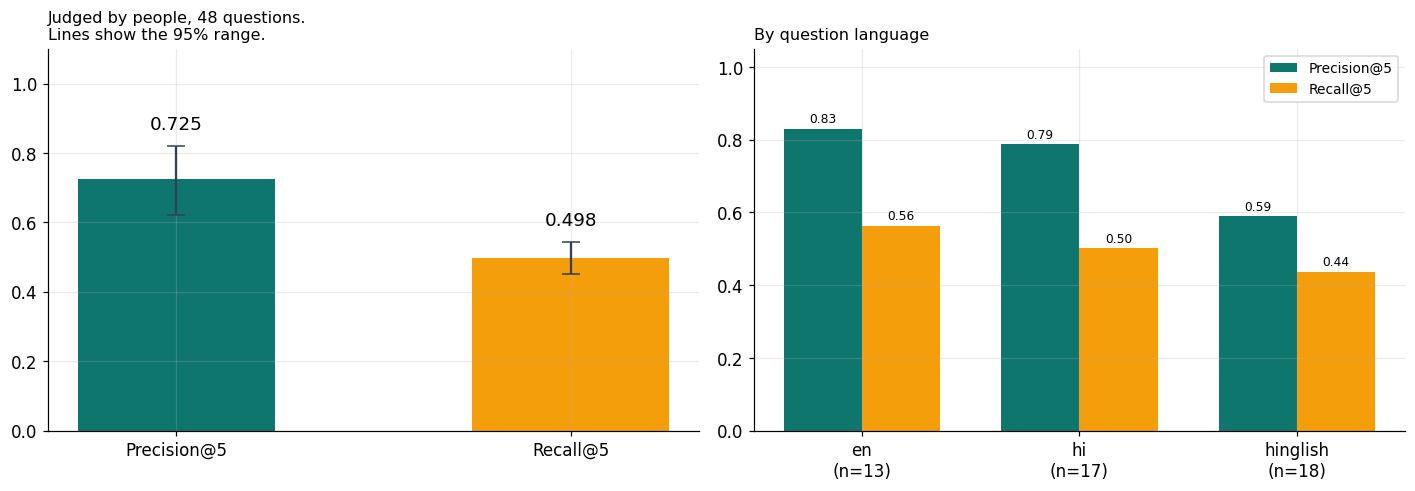

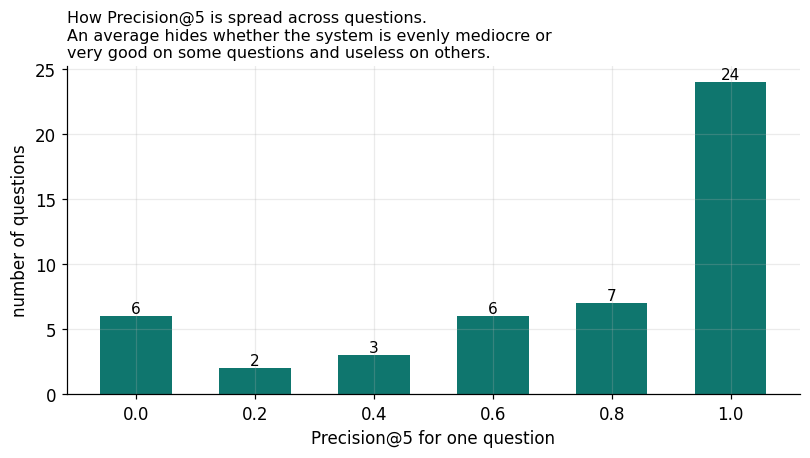

2 charts saved to /kaggle/working/human_eval/figures


In [16]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
FIGS = []

def _save(fig, name):
    p = os.path.join(FIG_DIR, name)
    fig.savefig(p, dpi=150, bbox_inches="tight")
    FIGS.append(p)

try:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

    ax = axes[0]
    vals = [SUM_DF["precision"].iloc[0], SUM_DF["recall"].iloc[0]]
    errs = [[vals[0] - SUM_DF["p_lo"].iloc[0], vals[1] - SUM_DF["r_lo"].iloc[0]],
            [SUM_DF["p_hi"].iloc[0] - vals[0], SUM_DF["r_hi"].iloc[0] - vals[1]]]
    b = ax.bar([f"Precision@{K}", f"Recall@{K}"], vals, width=0.5,
               color=["#0f766e", "#f59e0b"], yerr=errs, capsize=6, ecolor="#334155")
    ax.bar_label(b, fmt="%.3f", fontsize=12, padding=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"Judged by people, {len(RES)} questions.\n"
                 "Lines show the 95% range.", loc="left", fontsize=10.5)

    ax = axes[1]
    scripts = sorted(RES["script"].unique())
    x = np.arange(len(scripts)); w = 0.36
    pv = [RES[RES["script"] == s][f"P@{K}"].mean() for s in scripts]
    rv = [RES[RES["script"] == s][f"R@{K}"].mean() for s in scripts]
    b1 = ax.bar(x - w/2, pv, w, label=f"Precision@{K}", color="#0f766e")
    b2 = ax.bar(x + w/2, rv, w, label=f"Recall@{K}", color="#f59e0b")
    ax.bar_label(b1, fmt="%.2f", fontsize=8, padding=2)
    ax.bar_label(b2, fmt="%.2f", fontsize=8, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s}\n(n={int((RES['script']==s).sum())})" for s in scripts])
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
    ax.set_title("By question language", loc="left", fontsize=10.5)
    fig.tight_layout(); _save(fig, "01_precision_recall.png"); plt.show()
except Exception as e:
    print(f"[skip] main chart: {type(e).__name__}: {e}")

try:
    fig, ax = plt.subplots(figsize=(7.5, 4.3))
    counts = RES[f"P@{K}"].value_counts().sort_index()
    ax.bar([f"{v:.1f}" for v in counts.index], counts.values, color="#0f766e", width=0.6)
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=10)
    ax.set_xlabel(f"Precision@{K} for one question"); ax.set_ylabel("number of questions")
    ax.set_title(f"How Precision@{K} is spread across questions.\n"
                 "An average hides whether the system is evenly mediocre or\n"
                 "very good on some questions and useless on others.",
                 loc="left", fontsize=10.5)
    fig.tight_layout(); _save(fig, "02_spread.png"); plt.show()
except Exception as e:
    print(f"[skip] spread chart: {type(e).__name__}: {e}")

print(f"{len(FIGS)} charts saved to {FIG_DIR}")


## 13. Save

In [17]:
RES.to_csv(os.path.join(OUTPUT_DIR, "per_question_scores.csv"), index=False,
           encoding="utf-8-sig")
SUM_DF.to_csv(os.path.join(OUTPUT_DIR, "precision_recall_summary.csv"), index=False)

# every judgement, flat, so the labels can be checked or reused
flat = []
for qid, d in ALL_JUDGEMENTS.items():
    cands = {str(c["chunk_key"]): c for c in CANDIDATES.get(qid, [])}
    for key, vals in d.items():
        c = cands.get(key, {})
        for judge, val in vals:
            flat.append({"qid": qid, "chunk_key": key, "rank": c.get("rank"),
                         "judge": judge, "relevant": val,
                         "chunk_text": re.sub(r"\s+", " ", c.get("text", ""))[:600]})
pd.DataFrame(flat).to_csv(os.path.join(OUTPUT_DIR, "all_judgements.csv"),
                          index=False, encoding="utf-8-sig")

_withrel = RES[RES["has_any_relevant"]]
manifest = {
    "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "notebook": "13_retrieval_eval_human",
    "what_this_is": "Precision@5 and Recall@5 judged by people, not by a word-overlap formula.",
    "k": K,
    "collection": COLLECTION_NAME,
    "embed_model": EMBED_MODEL_NAME,
    "index_points": int(info.points_count),
    "retriever": "RRF over BGE-M3 dense + BM25" if USE_BM25 else "BGE-M3 dense only",
    "bm25_docs_indexed": _BM25["n"],
    "questions_total": int(len(EVAL_DF)),
    "questions_judged": int(len(RES)),
    "judge_depth": JUDGE_DEPTH,
    "chunks_judged": int(sum(len(d) for d in ALL_JUDGEMENTS.values())),
    "judges": sorted({j for d in ALL_JUDGEMENTS.values() for v in d.values() for j, _ in v}),
    "double_judged_chunks": len(_dbl),
    "agreement": (round(sum(1 for _, _, v in _dbl if len({x[1] for x in v}) == 1) / len(_dbl), 3)
                  if _dbl else None),
    "scores": json.loads(SUM_DF.to_json(orient="records")),
    "notes": {
        "recall_meaning": f"Recall@{K} is measured inside the top {JUDGE_DEPTH} chunks that were "
                          f"actually read, not across all {int(info.points_count):,} chunks in "
                          "the index. Say this when reporting the number.",
        "recall_denominator": f"Recall is averaged over the {len(_withrel)} questions that have "
                              "at least one relevant chunk. Questions with none are excluded "
                              "rather than scored as zero.",
        "skipped": "Chunks marked Skip are left out, not counted as not-relevant.",
        "sample_size": "48 questions. The confidence intervals are wide. Two numbers whose "
                       "intervals overlap should be treated as the same number.",
        "recall_at_5_caveat": (f"Recall@{K} is 1.0 by arithmetic because only {JUDGE_DEPTH} "
                               "chunks per question were judged." if JUDGE_DEPTH <= K else
                               f"Recall@{K} is meaningful: {JUDGE_DEPTH} chunks per question were "
                               f"judged and the top {K} scored against them."),
    },
    "figures": [os.path.basename(p) for p in FIGS],
}
with open(os.path.join(OUTPUT_DIR, "run_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False, default=str)

_bundle = os.path.join(OUT_ROOT, "human_eval_bundle")
shutil.rmtree(_bundle, ignore_errors=True)
shutil.make_archive(_bundle, "zip", OUTPUT_DIR)
print(f"saved to {OUTPUT_DIR}")
print(f"zip: {_bundle}.zip")
print("\nKeep judgements_*.json and candidates.json. Together they let anyone redo these")
print("numbers without judging anything again.")


saved to /kaggle/working/human_eval
zip: /kaggle/working/human_eval_bundle.zip

Keep judgements_*.json and candidates.json. Together they let anyone redo these
numbers without judging anything again.


## How to talk about these numbers

**Say who judged them.** "Precision@5 of 0.42, judged by two annotators over 48 questions" is a
much stronger sentence than "Precision@5 of 0.42". The judging is the contribution here.

**Say what Recall means.** Recall is measured inside the chunks that were actually read, not across
all 723,439 in the index. Written plainly, that is a normal and accepted method. Left unsaid, a
reader will assume something stronger than what was done.

**Compare against the automatic numbers.** The earlier notebook, using word overlap, gave
Precision@5 of 0.317. If the human number is much higher, the formula was calling correct chunks
wrong because they used different words — which is exactly what you would expect on Hindi text, and
is a finding worth a paragraph.

**Look at the questions that scored zero** before doing anything else. They usually share one
cause: a crop missing from the corpus, or a way of phrasing questions the embedder handles badly.
Fixing one cause often moves several questions at once, which is a better use of the time left than
tuning parameters.